In [1]:
# loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Part A: Data Preparation

### Task1

In [2]:
fear_greed = pd.read_csv('/content/drive/MyDrive/Prime_ass/fear_greed_index.csv')
trader     = pd.read_csv('/content/drive/MyDrive/Prime_ass/historical_data.csv')
for name, df in [("classifications", fear_greed), ("Traders", trader)]:
    print(f"\n{name}\n")
    print(f"  Shape      : {df.shape}")
    print(f"  Missing    : {df.isnull().sum().to_dict()}")
    print(f"  Duplicates : {df.duplicated().sum()}")


classifications

  Shape      : (2644, 4)
  Missing    : {'timestamp': 0, 'value': 0, 'classification': 0, 'date': 0}
  Duplicates : 0

Traders

  Shape      : (211224, 16)
  Missing    : {'Account': 0, 'Coin': 0, 'Execution Price': 0, 'Size Tokens': 0, 'Size USD': 0, 'Side': 0, 'Timestamp IST': 0, 'Start Position': 0, 'Direction': 0, 'Closed PnL': 0, 'Transaction Hash': 0, 'Order ID': 0, 'Crossed': 0, 'Fee': 0, 'Trade ID': 0, 'Timestamp': 0}
  Duplicates : 0


In [3]:
fear_greed.sample(5)

,timestamp,value,classification,date
1199,1621315800,21,Extreme Fear,2021-05-18
2501,1733895000,74,Greed,2024-12-11
494,1560403800,63,Greed,2019-06-13
800,1586842200,15,Extreme Fear,2020-04-14
119,1528003800,40,Fear,2018-06-03


In [4]:
trader.sample(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
149016,0xb899e522b5715391ae1d4f137653e7906c5e2115,SOL,138.200000,57.32,7921.62,SELL,09-03-2025 06:51,-5502.56,Open Short,0.000000,0x03993f8a67e1ccd19df0041f2e72e60201300049910f...,78292905151,True,1.980406,9.240000e+14,1.740000e+12
153291,0x2c229d22b100a7beb69122eed721cee9b24011dd,AIXBT,0.519190,381.00,197.81,SELL,10-01-2025 14:32,72304.00,Close Long,23.599140,0x00a1b75645bc107849b7041b1c4f8002013c00fe885e...,62011057623,False,0.019781,8.000000e+14,1.740000e+12
176053,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,15.239000,35.00,533.37,BUY,07-03-2025 03:17,1182.74,Open Long,0.000000,0x4285da2b96fe2e6a6316041f0b24f0016200fc696973...,77760854344,True,0.160009,3.560000e+14,1.740000e+12
45824,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,@107,22.600000,3.18,71.87,SELL,14-12-2024 21:17,52132.34,Sell,71.867969,0xf070eab643119f27a74004193929d001ab00c47e59b8...,55417872495,True,0.025153,8.490000e+14,1.730000e+12
35579,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,JELLY,0.005114,190000.00,971.66,SELL,18-02-2025 15:54,1007835.00,Close Long,29.260000,0xaf00e25de8c5445f7cd4041dfd2e78018600953a5ab0...,73131469070,True,0.326477,3.560000e+14,1.740000e+12


### Task2

In [5]:
fear_greed.sample(5)

,timestamp,value,classification,date
1696,1664256600,20,Extreme Fear,2022-09-27
1169,1618723800,79,Extreme Greed,2021-04-18
68,1523338200,18,Extreme Fear,2018-04-10
1179,1619587800,59,Greed,2021-04-28
1414,1639891800,29,Fear,2021-12-19


In [6]:
trader.sample(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
19412,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,JUP,1.2082,2900.00,3503.78,SELL,26-01-2025 19:44,-15550.00,Open Short,0.000000,0xba46c955345771d5fb3f041c8eeebb01f40052cbab5f...,66654524067,True,1.226323,3.990000e+14,1.740000e+12
117781,0x8170715b3b381dffb7062c0298972d4727a0a63b,MELANIA,0.4926,1760.00,866.98,SELL,11-04-2025 02:39,-979885.30,Open Short,0.000000,0xa6036add2a43985057a704214c027701af005b17ed52...,85668657196,False,0.083229,7.730000e+13,1.740000e+12
68792,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,19.3530,1.62,31.35,BUY,25-02-2025 07:24,242565.29,Open Long,0.000000,0x0e554e12d49f7d8f4773041e692bc302014d0049665d...,74607648910,False,0.001504,2.170000e+14,1.740000e+12
146439,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,SOL,117.6700,5.00,588.35,BUY,09-04-2025 23:48,-62.04,Close Short,1.578500,0x1e82ed6d5ecf01a325e40421398c6d02061500dbf707...,85388239365,False,0.058835,6.410000e+14,1.740000e+12
130815,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,SUI,3.3894,14.70,49.82,BUY,25-11-2024 18:13,-104.60,Close Short,0.737793,0x42bb19e7ec08c467fd5a0417ace0ec01690067c36814...,50129926387,True,0.017438,7.830000e+14,1.730000e+12


In [7]:
trader[trader['Side']=='BUY']

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211086,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1540,600.10,692.52,BUY,23-04-2025 15:30,96335.100000,Open Long,0.0,0x8fea713978b76316eaec042216cffe02048100b95383...,88264995359,False,0.069251,3.170000e+14,1.750000e+12
211087,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1540,455.10,525.19,BUY,23-04-2025 15:30,96935.200000,Open Long,0.0,0x23b6fa667f348fbbdba0042216cfff0203cd0069f202...,88264995359,False,0.052518,8.770000e+14,1.750000e+12
211088,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1540,2295.00,2648.43,BUY,23-04-2025 15:30,97390.300000,Open Long,0.0,0x01515f86120564623856042216cfff0203d7000563f7...,88264995359,False,0.264843,5.190000e+14,1.750000e+12
211089,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1540,13.00,15.00,BUY,23-04-2025 15:30,99685.300000,Open Long,0.0,0x6b6eabeae957826a529b042216d0000202b400210200...,88264995359,False,0.001500,8.720000e+13,1.750000e+12


In [8]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [9]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [10]:
import datetime

# 2. Converting timestamps
trader["Timestamp IST"] = pd.to_datetime(trader["Timestamp IST"], dayfirst=True)
trader['date'] = trader['Timestamp IST'].dt.date

fear_greed['datetime'] = pd.to_datetime(fear_greed['timestamp'], unit='s')
fear_greed['date'] = fear_greed['datetime'].dt.date

# Merging datasets
merged = trader.merge(fear_greed[['date','classification','value']], on='date', how='left')
print(f"Merged rows    : {len(merged):,}")
print(f"Sentiment nulls: {merged['classification'].isnull().sum()}")

# 3
merged['win'] = (merged['Closed PnL'] > 0).astype(int)

daily = (merged
    .groupby(['Account', 'date', 'classification'])
    .agg(
        daily_pnl    = ('Closed PnL',  'sum'),
        n_trades     = ('Closed PnL',  'size'),
        winning_trades = ('win', 'sum'),
        win_rate = ('win', 'mean'),
        avg_size_usd = ('Size USD',     'mean'),
        long_trades  = ('Side', lambda x: (x == 'BUY').sum()),
        short_trades = ('Side', lambda x: (x == 'SELL').sum()),

    ).reset_index())
daily['long_ratio'] = daily['long_trades'] / daily['n_trades']
daily['short_ratio'] = daily['short_trades'] / daily['n_trades']

print(f"\nDaily (per account per day) rows: {len(daily):,}")
daily.sample(5)

Merged rows    : 211,224
Sentiment nulls: 6

Daily (per account per day) rows: 2,340


,Account,date,classification,daily_pnl,n_trades,winning_trades,win_rate,avg_size_usd,long_trades,short_trades,long_ratio,short_ratio
69,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-04-23,Greed,2654.143150,568,336,0.591549,2593.251549,219,349,0.385563,0.614437
392,0x39cef799f8b69da1995852eea189df24eb5cae3c,2025-03-20,Neutral,0.000000,82,0,0.000000,607.780244,0,82,0.000000,1.000000
1578,0x8477e447846c758f5a675856001ea72298fd9cb5,2025-01-18,Extreme Greed,1055.804444,40,20,0.500000,565.994250,22,18,0.550000,0.450000
1248,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,2024-12-21,Greed,24.404600,8,4,0.500000,1607.236250,4,4,0.500000,0.500000
735,0x4f93fead39b70a1824f981a54d4e55b278e9f760,2024-05-13,Greed,2136.853859,25,10,0.400000,7525.763600,5,20,0.200000,0.800000


<Axes: xlabel='leverage_bucket'>

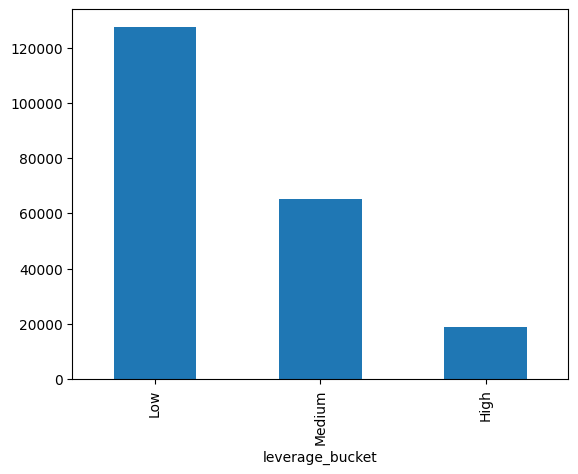

In [18]:
trader['leverage_bucket'] = pd.cut(
    trader['Size USD'],
    bins=[0, 1000, 10000, trader['Size USD'].max()],
    labels=['Low', 'Medium', 'High']
)
trader['leverage_bucket'].value_counts().plot(kind='bar')

##### Trade size (USD) was used as a proxy for leverage. The distribution shows that the majority of trades fall into the low leverage category, with significantly fewer medium and high leverage trades. This indicates that most traders adopt conservative position sizing, while only a small fraction engage in high-risk, high-leverage trading.

### Part B Analysis

In [14]:
daily['drawdown_proxy'] = daily['daily_pnl'].apply(lambda x: abs(x) if x < 0 else 0)
daily.groupby('classification').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'drawdown_proxy': 'mean'
})

,daily_pnl,win_rate,drawdown_proxy
classification,,,
Extreme Fear,4619.439053,0.329659,3009.860125
Extreme Greed,5161.922644,0.386387,429.772382
Fear,5328.818161,0.364033,616.774281
Greed,3318.100730,0.343559,1329.091088
Neutral,3438.618818,0.355414,768.448153


#### Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
Yes, performance differs significantly across sentiment regimes.

This is evident from variations in PnL, win rate, and drawdown proxy:
1. PnL varies across sentiment
- Fear has the highest PnL (~5328)
- Extreme Greed also shows high PnL (~5161)
- Greed has much lower PnL (~3318)

Conclusion: Profitability is not uniform and depends on sentiment.

2. Win rate differs
- Highest in Extreme Greed (~38.6%)
- Lowest in Extreme Fear (~32.9%)

Conclusion: Traders are more successful during Extreme Greed than Extreme Fear.

3. Risk (Drawdown Proxy) differs strongly
- Extreme Fear has very high drawdown (~3009)
- Extreme Greed has very low drawdown (~429)

Conclusion: Risk is much higher during fear conditions.


Insight - Hence even though Fear gives high PnL, it comes with high risk whereas Extreme Greed gives better risk-adjusted performance


In [45]:
behaviour = daily.groupby('classification').agg({
    'n_trades': 'mean',
    'avg_size_usd': 'mean',
    'long_ratio': 'mean',
    'short_ratio': 'mean'
}).reset_index()

order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
behaviour['classification'] = pd.Categorical(behaviour['classification'], categories=order, ordered=True)
behaviour = behaviour.sort_values('classification')

print(behaviour)

  classification    n_trades  avg_size_usd  long_ratio  short_ratio
0   Extreme Fear  133.750000   6773.464125    0.531533     0.468467
2           Fear   98.153968   8975.928546    0.518967     0.481033
4        Neutral  100.228723   6963.694861    0.472431     0.527569
3          Greed   77.628086   6427.866594    0.471594     0.528406
1  Extreme Greed   76.030418   5371.637182    0.473116     0.526884


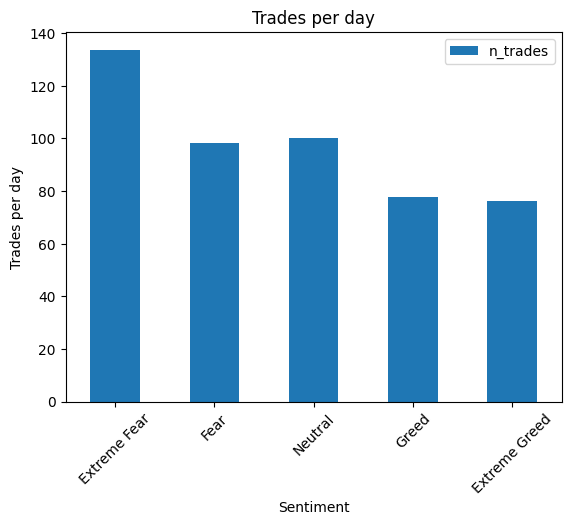

In [46]:
behaviour.plot(x='classification', y='n_trades', kind='bar')
plt.title("Trades per day")
plt.xlabel("Sentiment")
plt.ylabel("Trades per day")
plt.xticks(rotation=45)
plt.show()





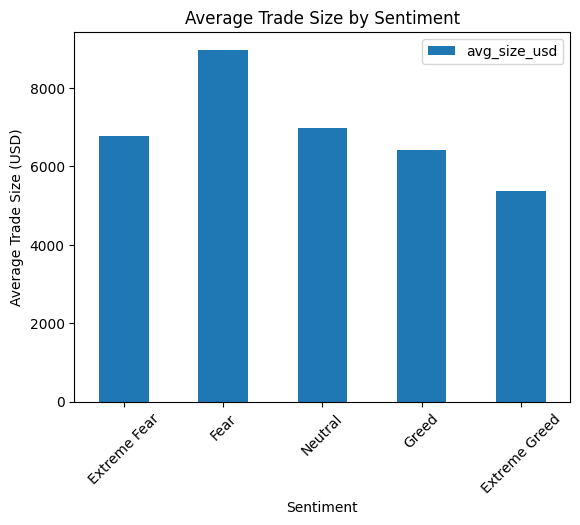

In [47]:

behaviour.plot(x='classification', y='avg_size_usd', kind='bar')
plt.title("Average Trade Size by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)
plt.show()

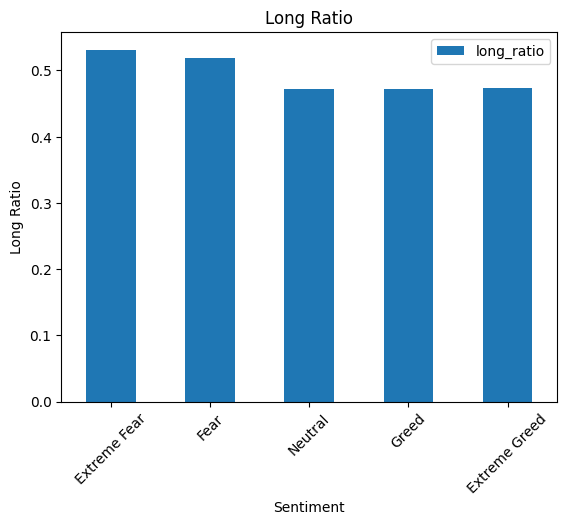

In [48]:
behaviour.plot(x='classification', y='long_ratio', kind='bar')
plt.title("Long Ratio")
plt.xlabel("Sentiment")
plt.ylabel("Long Ratio")
plt.xticks(rotation=45)
plt.show()

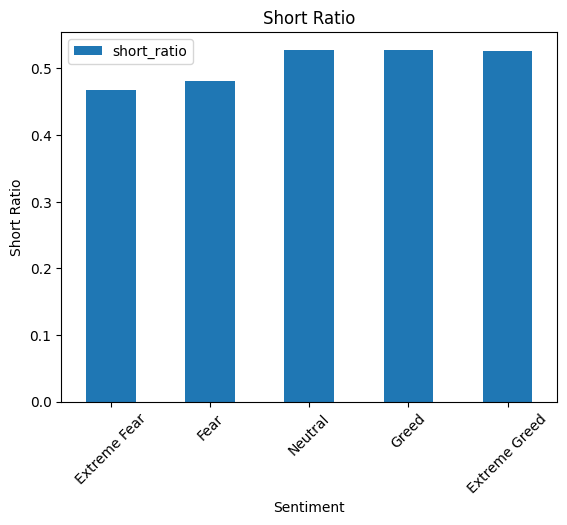

In [49]:
behaviour.plot(x='classification', y='short_ratio', kind='bar')
plt.title("Short Ratio")
plt.xlabel("Sentiment")
plt.ylabel("Short Ratio")
plt.xticks(rotation=45)
plt.show()

Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


Yes, traders change behavior significantly based on market sentiment.

This is evident from variations in trade frequency, position size (leverage proxy), and long/short bias.

1. Trade Frequency
- Highest during Extreme Fear (~133 trades/day)
- Lowest during Extreme Greed (~76 trades/day)

Traders are more active during fear conditions

2. Position Size / Leverage
- Highest during Fear (~8975 USD)
- Lowest during Extreme Greed (~5371 USD)

Traders take larger and riskier positions during Fear
and they become more conservative during Greed.

3. Long/Short Bias
- Fear -> higher long ratio (~0.52–0.53)
- Greed -> higher short ratio (~0.52–0.53)

So traders
Prefer BUY (long) in Fear
and shift towards SELL (short) in Greed.

Insights: Trader behaviour becomes more aggressive during Fear periods, with higher trading frequency and larger position sizes, while Greed periods are associated with reduced activity and relatively more short-biased positions.

In [27]:
# Average size per account
account_stats = daily.groupby('Account').agg({
    'avg_size_usd': 'mean',
    'n_trades': 'mean',
    'win_rate': 'mean',
    'daily_pnl': 'mean'
}).reset_index()

# Create leverage segments
account_stats['leverage_segment'] = pd.qcut(
    account_stats['avg_size_usd'],
    q=2,
    labels=['Low Leverage', 'High Leverage']
)

In [28]:
account_stats.groupby('leverage_segment').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean'
})

/tmp/ipykernel_699/14495015.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  account_stats.groupby('leverage_segment').agg({


,daily_pnl,win_rate
leverage_segment,,
Low Leverage,4929.798775,0.374586
High Leverage,9324.283024,0.328333


High leverage traders generate higher returns but also exhibit lower win rates, indicating increased risk. Low leverage traders show more stable and consistent performance.

In [30]:
account_stats['frequency_segment'] = pd.qcut(
    account_stats['n_trades'],
    q=2,
    labels=['Infrequent', 'Frequent']
)
account_stats.groupby('frequency_segment').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean'
})

/tmp/ipykernel_699/3589348711.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  account_stats.groupby('frequency_segment').agg({


,daily_pnl,win_rate
frequency_segment,,
Infrequent,3541.023675,0.319796
Frequent,10713.058123,0.383123


Frequent traders outperform infrequent traders in both profitability and win rate. This suggests that higher market participation leads to better performance, indicating that active trading strategies may be more effective in this dataset

In [31]:
account_stats['consistency_segment'] = pd.qcut(
    account_stats['win_rate'],
    q=2,
    labels=['Inconsistent', 'Consistent']
)
account_stats.groupby('consistency_segment').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean'
})

/tmp/ipykernel_699/1083175987.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  account_stats.groupby('consistency_segment').agg({


,daily_pnl,win_rate
consistency_segment,,
Inconsistent,5795.763220,0.266691
Consistent,8458.318578,0.436228


Consistent traders achieve significantly higher profitability and win rates compared to inconsistent traders. This highlights the importance of maintaining disciplined and reliable trading strategies.

In [51]:
comparison = daily.groupby('classification').agg({
    'daily_pnl':'mean',
    'win_rate':'mean',
    'drawdown_proxy':'mean',
    'n_trades':'mean',
    'avg_size_usd':'mean',
}).reset_index()

print(comparison)

  classification    daily_pnl  win_rate  drawdown_proxy    n_trades  \
0   Extreme Fear  4619.439053  0.329659     3009.860125  133.750000   
1  Extreme Greed  5161.922644  0.386387      429.772382   76.030418   
2           Fear  5328.818161  0.364033      616.774281   98.153968   
3          Greed  3318.100730  0.343559     1329.091088   77.628086   
4        Neutral  3438.618818  0.355414      768.448153  100.228723   

   avg_size_usd  
0   6773.464125  
1   5371.637182  
2   8975.928546  
3   6427.866594  
4   6963.694861  


##### Insight 1: Performance varies with sentiment
Table: Sentiment versus Performance

| Classification | Daily PnL | Win Rate | Drawdown |
| -------------- | --------- | -------- | -------- |
| Extreme Fear   | 4619      | 0.329    | 3009     |
| Extreme Greed  | 5161      | 0.386    | 429      |
| Fear           | 5328      | 0.364    | 616      |
| Greed          | 3318      | 0.343    | 1329     |
| Neutral        | 3438      | 0.355    | 768      |

As shown in the above table, trader performance varies significantly across sentiment regimes. Fear conditions yield the
highest average PnL ( 5328),while Extreme Greed shows the highest win rate (approx 0.386) along with the lowest drawdown (429), indicating better risk-adjusted performance. In contrast, Extreme Fear exhibits the highest drawdown (3009), suggesting higher risk and instability.

##### Insight 2: Behavior changes with sentiment
Figure: Trade Frequency by Sentiment



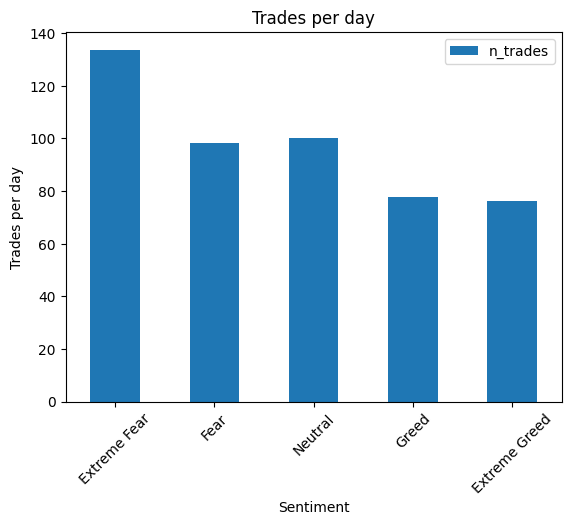

Figure: Average Trade Size by Sentiment

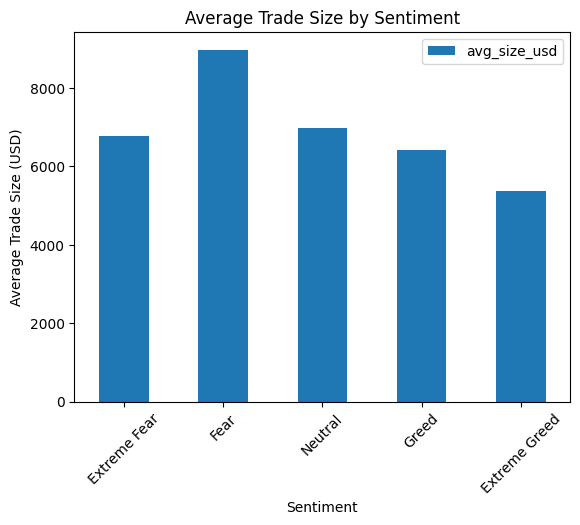


As illustrated in the above figures, traders are more active and take larger positions during Fear periods, indicating more aggressive behavior.


Insight 3: Segmentation results

| Frequency Segment | Daily PnL | Win Rate |
| ----------------- | --------- | -------- |
| Infrequent        | 3541      | 0.319    |
| Frequent          | 10713     | 0.383    |

This indicates that increased trading activity is associated with better performance in this dataset, suggesting that active participation may provide more opportunities for profit.

### Part C

Propose 2 strategy ideas or “rules of thumb” based on your findings.
Example: “During Fear days, reduce leverage for segment X; increase trade frequency only for segment Y.”


Strategy 1: Adjust position size based on sentiment
During Fear and Extreme Fear periods, traders should reduce position sizes (leverage), as these conditions are associated with higher drawdowns and increased risk. In contrast, during Extreme Greed, traders can maintain or slightly increase position sizes due to more stable and favorable market conditions.

Strategy 2: Increase activity selectively for consistent/frequent traders
Frequent and consistent traders should maintain higher trading activity, as they demonstrate higher profitability and win rates. Infrequent or inconsistent traders should avoid overtrading and instead focus on fewer, high-quality trades.

Strategy 3: Directional bias adjustment based on sentiment
During Fear periods, traders may benefit from maintaining a long (buy) bias, as data shows higher long ratios and profitable outcomes. During Greed periods, traders should be cautious and consider increasing short exposure due to reduced performance and shifting market dynamics.

### Bonus part

In [52]:
## creating target and categorical feature encoding
daily['target'] = (daily['daily_pnl'] > 0).astype(int)
features = [
    'n_trades',
    'avg_size_usd',
    'long_ratio',
    'short_ratio'
]
daily = pd.get_dummies(daily, columns=['classification'], drop_first=True)

In [53]:
# Training model; using random forest as there is nonlinear relation in data and mixed type columns and data is not scaled
X = daily[features + [col for col in daily.columns if 'classification_' in col]]
y = daily['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [54]:


y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8098290598290598


A Random Forest classifier was trained to predict whether a trader would be profitable on a given day using behavioral features and market sentiment. The model achieved an accuracy of approximately 80%, indicating that trading behavior (such as trade frequency and position size) along with market sentiment are strong predictors of profitability. This suggests that trader performance is not random and can be partially explained using observable features.


In [56]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False)

,0
avg_size_usd,0.298484
n_trades,0.237416
short_ratio,0.214145
long_ratio,0.207913
classification_Extreme Greed,0.012793
classification_Greed,0.010494
classification_Neutral,0.009405
classification_Fear,0.009350


Feature importance analysis reveals that trading behavior plays a significantly larger role in predicting profitability compared to market sentiment. Position size (avg_size_usd) emerges as the most important predictor, followed by trade frequency (n_trades) and directional ratios. In contrast, sentiment variables contribute relatively less to the model. This suggests that how traders act in the market is more critical than overall market sentiment in determining outcomes.